<a href="https://colab.research.google.com/github/aavarela/SPBD_Labs/blob/main/report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 1 Report
The goal of this project is to analyse a dataset containing the records of taxi trips in the New York city area collected circa 2013.

Due to the large amount of the complete dataset (\~33GB expanded) only a 1% sample (\~120MB) is used here.

Additionally, as the dataset contains historical data with no time references, instead of considering only "the trips that started in the area and ended within the last 15 minutes" we used "the trips that started in the area with a duration of 15 minutes or less" to filter the taxi rides used in the calculation of the average profitability of each area.

This work was carried out by Afonso Varela (73544) and Gonçalo Dionísio (73638), with the help of Google Gemini 3 Pro (AI agent).

In [ ]:
#@title Java Setup (needed for pyspark)
!apt-get install -y openjdk-17-jre 2>/dev/null > /dev/null

In [ ]:
#@title Download 1% sample
!wget -q -O taxi_rides_1pc.csv.gz https://www.dropbox.com/scl/fi/v8ei5laqcalrx30z3lsty/taxi_rides_1pc.csv.gz?rlkey=q1lq7l56c4j97h9kymsdroau5&st=iurdwnwj&dl=0

In [ ]:
#@title Inspect dataset schema
from pyspark.sql import *
from pyspark.sql.types import *
from pyspark.sql.functions import *

# Start a Spark session
spark = SparkSession.builder.master('local[*]').appName('taxis').getOrCreate()

try :
    # Read dataset
    data = spark.read.csv('taxi_rides_1pc.csv.gz', sep =',', header=True, inferSchema=True)

    # Show dataset schema
    data.printSchema()

except Exception as err:
    print(err)

root
 |-- medallion: string (nullable = true)
 |-- hack_license: string (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- trip_time_in_secs: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- surcharge: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)



In [ ]:
#@title Clean the data
from pyspark.sql.functions import col, isnan, when, floor

# Filter out rows with null or invalid coordinate values
cleaned_data = data.filter(
    col("pickup_latitude").isNotNull() & ~isnan(col("pickup_latitude")) &
    col("pickup_longitude").isNotNull() & ~isnan(col("pickup_longitude")) &
    col("dropoff_latitude").isNotNull() & ~isnan(col("dropoff_latitude")) &
    col("dropoff_longitude").isNotNull() & ~isnan(col("dropoff_longitude"))
)

# Longitude and latitude from the upper left corner of the grid
MIN_LON = -74.916578
MAX_LAT = 41.47718278

# Longitude and latitude that correspond to a shift in 500 meters
LON_DELTA = 0.005986
LAT_DELTA = 0.004491556

# Convert coordinates (latitude,longitude) to grids (x,y)
data_with_grid_coords = cleaned_data \
    .withColumn("pickup_grid_x", floor((MAX_LAT - col("pickup_latitude")) / LAT_DELTA)) \
    .withColumn("pickup_grid_y", floor((col("pickup_longitude") - MIN_LON) / LON_DELTA)) \
    .withColumn("dropoff_grid_x", floor((MAX_LAT - col("dropoff_latitude")) / LAT_DELTA)) \
    .withColumn("dropoff_grid_y", floor((col("dropoff_longitude") - MIN_LON) / LON_DELTA))

# Filter the DataFrame to include only trips within the 300x300 grid for both
# pickup and dropoff and also filter out trips with zero or negative distance.
filtered_data = data_with_grid_coords.filter(
    (col("pickup_grid_x") > 0) & (col("pickup_grid_x") < 300) &
    (col("pickup_grid_y") > 0) & (col("pickup_grid_y") < 300) &
    (col("dropoff_grid_x") > 0) & (col("dropoff_grid_x") < 300) &
    (col("dropoff_grid_y") > 0) & (col("dropoff_grid_y") < 300) &
    (col("trip_distance") > 0) # Filter out trips with zero or negative distance
)

In [ ]:
#@title Calculate the profit (fare+tip) for each trip
final_data = filtered_data.withColumn("trip_profit", col("fare_amount") + col("tip_amount"))

In [ ]:
#@title Display cleaning results and final data schema
print("Original DataFrame count:", data.count())
print("Cleaned DataFrame count (after removing null coords):", cleaned_data.count())
print("DataFrame with grid coordinates, filtered and profit count:", final_data.count())
final_data.printSchema()

Original DataFrame count: 1735010
Cleaned DataFrame count (after removing null coords): 1734973
DataFrame with grid coordinates, filtered and profit count: 1691820
root
 |-- medallion: string (nullable = true)
 |-- hack_license: string (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- trip_time_in_secs: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- surcharge: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- pickup_grid_x: long (nullable = true)
 |-- pickup_grid_y

#Q1: Are some areas more profitable than others?

The profitability of a pickup area is determined by dividing the area profit by the number of empty taxis in that area within the last 15 minutes.

1. The area profit is computed by calculating the average profit (fare+tip) for trips that started in the area and ended within 15 minutes from the pickup time.

2. The number of empty taxis in the area is the sum of taxis that had a drop-off location in that area less than 30 minutes ago and had no following pickup yet.

3. Calculate the area profitability by dividing the average area profit by the number of empty taxis in that area.

In [ ]:
#@title Calculate average profit and number of empty taxis per area
from pyspark.sql.functions import avg, col, unix_timestamp
from pyspark.sql.functions import lead, count, datediff, when, lit
from pyspark.sql.window import Window

# Calculate trip duration in minutes
# (unix_timestamp returns seconds, so divide by 60 for minutes)
filtered_for_profit_calculation = final_data.withColumn(
    "trip_duration_minutes",
    (unix_timestamp(col("dropoff_datetime")) - unix_timestamp(col("pickup_datetime"))) / 60
)

# Filter to include only trips where the duration is 15 minutes or less
filtered_for_profit_calculation = filtered_for_profit_calculation.filter(col("trip_duration_minutes") <= 15)

# Group by pickup grid coordinates and calculate the average trip_profit for the filtered data
avg_profit_per_pickup_area = filtered_for_profit_calculation.groupBy("pickup_grid_x", "pickup_grid_y").agg(avg("trip_profit").alias("avg_trip_profit"))

# Define the window specification: partition by medallion, order by pickup_datetime
window_spec = Window.partitionBy("medallion").orderBy("pickup_datetime")

# Add next_pickup_datetime
data_with_next_pickup = final_data.withColumn(
    "next_pickup_datetime",
    lead(col("pickup_datetime"), 1).over(window_spec)
)

# Calculate time_to_next_pickup_minutes convereting timestamps to Unix
# timestamps (seconds) for accurate difference calculation
data_with_next_pickup = data_with_next_pickup.withColumn(
    "time_to_next_pickup_minutes",
    (unix_timestamp(col("next_pickup_datetime")) - unix_timestamp(col("dropoff_datetime"))) / 60
)

# Create is_empty_taxi status by flagging data for which the next_pickup_datetime
# is null (last trip) or the time_to_next_pickup_minutes is > 30
final_data_with_empty_status = data_with_next_pickup.withColumn(
    "is_empty_taxi",
    when(
        (col("next_pickup_datetime").isNull()) | (col("time_to_next_pickup_minutes") > 30),
        True
    ).otherwise(False)
)

# Calculate the count of empty taxi instances per dropoff grid area
empty_taxi_count_per_dropoff_area = final_data_with_empty_status.filter(
    col("is_empty_taxi") == True
).groupBy("dropoff_grid_x", "dropoff_grid_y") \
 .agg(count("medallion").alias("empty_taxi_count"))

In [ ]:
#@title Calculate area profitability
from pyspark.sql.functions import col, when, desc

# Join the two DataFrames on matching grid coordinates
area_profitability = avg_profit_per_pickup_area.join(
    empty_taxi_count_per_dropoff_area,
    (avg_profit_per_pickup_area["pickup_grid_x"] == empty_taxi_count_per_dropoff_area["dropoff_grid_x"]) &
    (avg_profit_per_pickup_area["pickup_grid_y"] == empty_taxi_count_per_dropoff_area["dropoff_grid_y"]),
    "inner" # Use inner join to only consider areas present in both
)

# Calculate the profitability ratio, handling division by zero
area_profitability = area_profitability.withColumn(
    "profitability",
    when(col("empty_taxi_count") > 0,
         col("avg_trip_profit") / col("empty_taxi_count"))
    .otherwise(0.0) # Assign 0.0 or another suitable value if empty_taxi_count is zero
)

# Order the output by profitability ratio in descending order
area_profitability = area_profitability.orderBy(desc("profitability"))

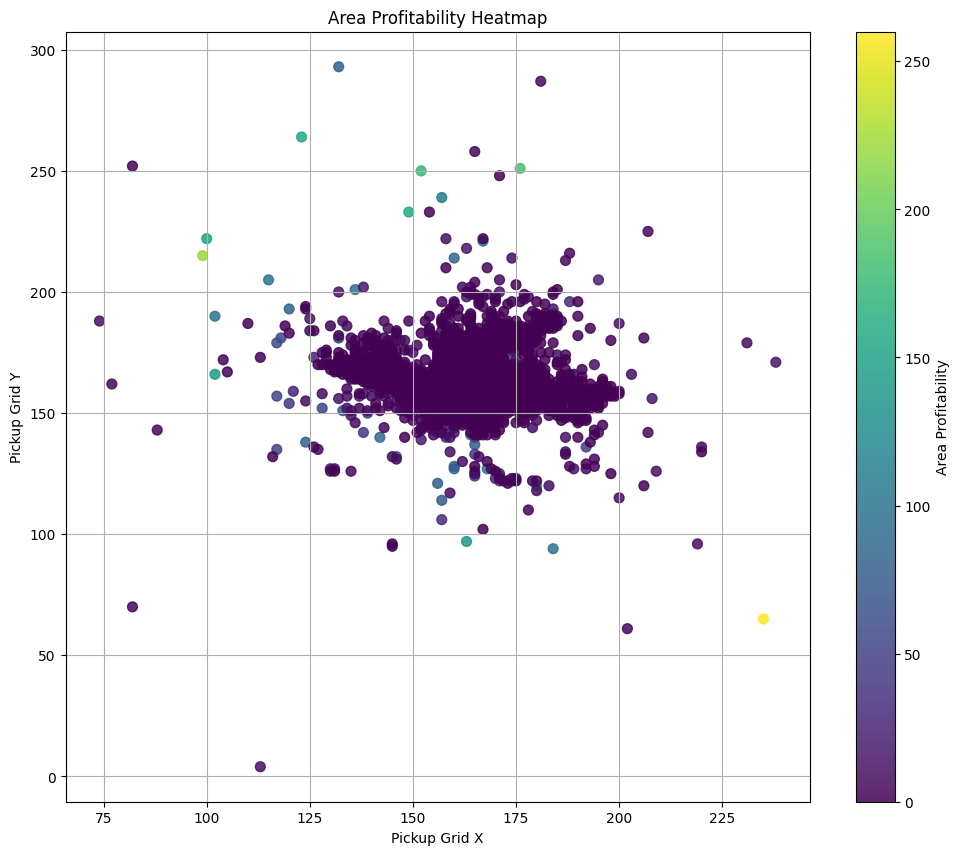

In [18]:
#@title Heat map visualization of the profitability data to highlight the most profitable areas.
import matplotlib.pyplot as plt

# Convert the Spark DataFrame to a Pandas DataFrame for visualization
profitability_df_pd = area_profitability.toPandas()

# Create a scatter plot
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    profitability_df_pd['pickup_grid_x'],
    profitability_df_pd['pickup_grid_y'],
    c=profitability_df_pd['profitability'], # Color by profitability
    cmap='viridis', # Colormap
    s=50, # Size of the points
    alpha=0.85 # Transparency of the points
)

plt.colorbar(scatter, label='Area Profitability')
plt.xlabel('Pickup Grid X')
plt.ylabel('Pickup Grid Y')
plt.title('Area Profitability Heatmap')
plt.grid(True)
plt.show()

#Obervations
Observing the heat map of the average profitability we can conclude that the majority of the areas generate low profit while some of the areas generate high levels of profit. This is confirmed by the key summary statistics shown below.

In [ ]:
#@title Key summary statistics of the profitability data
from pyspark.sql.functions import min, max, mean, stddev, count

# Calculate key summary statistics
summary_stats_agg = area_profitability.agg(
    min('profitability').alias('min_profitability'),
    max('profitability').alias('max_profitability'),
    mean('profitability').alias('mean_profitability'),
    stddev('profitability').alias('stddev_profitability'),
    count('profitability').alias('count_profitability')
)
summary_stats_agg.show()

+-----------------+-----------------+------------------+--------------------+-------------------+
|min_profitability|max_profitability|mean_profitability|stddev_profitability|count_profitability|
+-----------------+-----------------+------------------+--------------------+-------------------+
|              0.0|            260.0| 4.285668615470877|  17.321423436056918|               1719|
+-----------------+-----------------+------------------+--------------------+-------------------+



#Obervations
The key summary statistics confirm our observations from the heat map visualization, with the low value of the average profitability and the relatively high standard deviation.

To obtain further insight about the distribution of the area profitability data we plot the histogram and the boxplot of the profitability data.

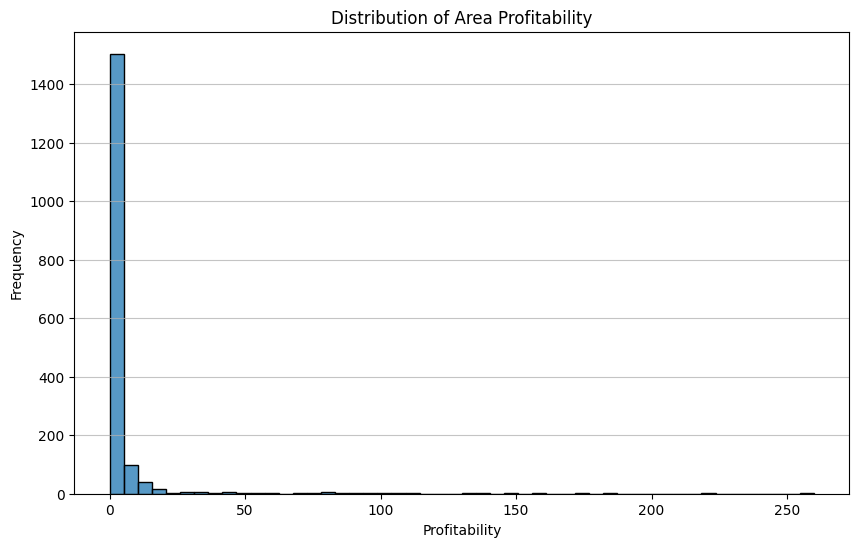

In [ ]:
#@title Histogram of the profitability data
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the 'profitability' column to a Pandas Series for plotting
profitability_pd = area_profitability.select('profitability').toPandas()['profitability']

# Show histogram
plt.figure(figsize=(10, 6))
sns.histplot(profitability_pd, bins=50)
plt.title('Distribution of Area Profitability')
plt.xlabel('Profitability')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

The histogram of the profitability data confirms our observation from the heat map, showing that the distribution is right-skewed with the majority of the trips generating low profit and only some of the trips being substantially profitable.

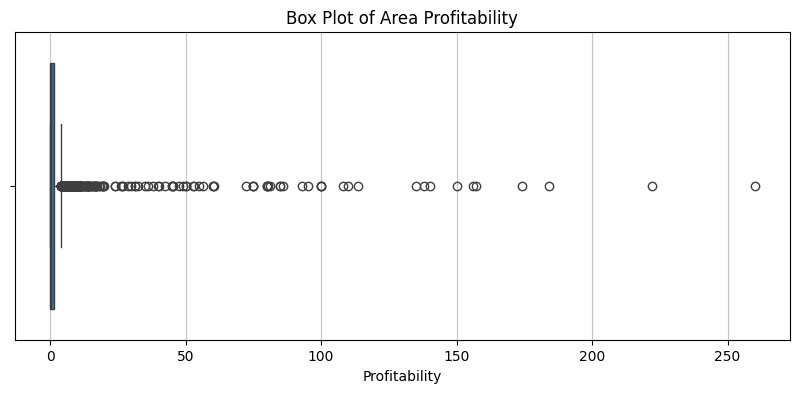

In [ ]:
#@title Boxplot of the profitability data
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the 'profitability' column to a Pandas Series for plotting
profitability_pd = area_profitability.select('profitability').toPandas()['profitability']

# Show boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=profitability_pd)
plt.title('Box Plot of Area Profitability')
plt.xlabel('Profitability')
plt.grid(axis='x', alpha=0.75)
plt.show()

The box plot further confirms the right-skewness and highlights the presence of numerous outliers on the higher end, meaning a few trips generate exceptionally high profits compared to the majority.

To assess the reason for these observations we will study the dependences of the trip profit with the trip distance (Q2) and time of day (Q3).

#Q2: How do the profitability varies with the trip distance?

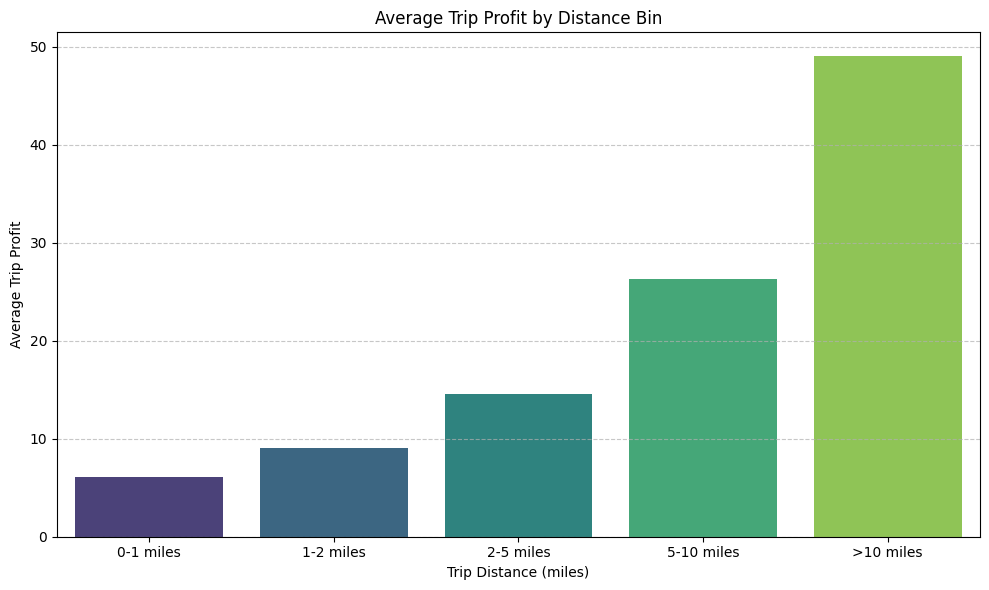

In [ ]:
#@title Visualize the trip profits as a funtion of the trips distance
from pyspark.sql.functions import avg, col, when
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define distance bins to group data by trip_distance
final_data_with_bins = final_data.withColumn(
    "distance_bin",
    when((col("trip_distance") >= 0) & (col("trip_distance") < 1), "0-1 miles")
    .when((col("trip_distance") >= 1) & (col("trip_distance") < 2), "1-2 miles")
    .when((col("trip_distance") >= 2) & (col("trip_distance") < 5), "2-5 miles")
    .when((col("trip_distance") >= 5) & (col("trip_distance") < 10), "5-10 miles")
    .otherwise(">10 miles")
)

# Group by distance_bin and calculate the average trip_profit
avg_profit_by_distance = final_data_with_bins.groupBy("distance_bin").agg(avg("trip_profit").alias("average_trip_profit"))

# Define the order for distance bins for better visualization
distance_bin_order = ["0-1 miles", "1-2 miles", "2-5 miles", "5-10 miles", ">10 miles"]

# Convert to Pandas DataFrame and reorder the bins
avg_profit_by_distance_pd = avg_profit_by_distance.toPandas()
avg_profit_by_distance_pd['distance_bin'] = pd.Categorical(avg_profit_by_distance_pd['distance_bin'], categories=distance_bin_order, ordered=True)
avg_profit_by_distance_pd = avg_profit_by_distance_pd.sort_values('distance_bin')

# Create a bar plot to visualize average trip profit by distance bin
plt.figure(figsize=(10, 6))
sns.barplot(x='distance_bin',
            y='average_trip_profit',
            data=avg_profit_by_distance_pd,
            palette='viridis',
            hue='distance_bin',
            legend=False)

plt.title('Average Trip Profit by Distance Bin')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Average Trip Profit')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

As can be observed, there is a clear positive correlation between the trip distance and the trip profit, with longer trips consistently generating higher profits, with trips over 10 miles being the most profitable.

#Q3: How do the profitability varies with the time of day?

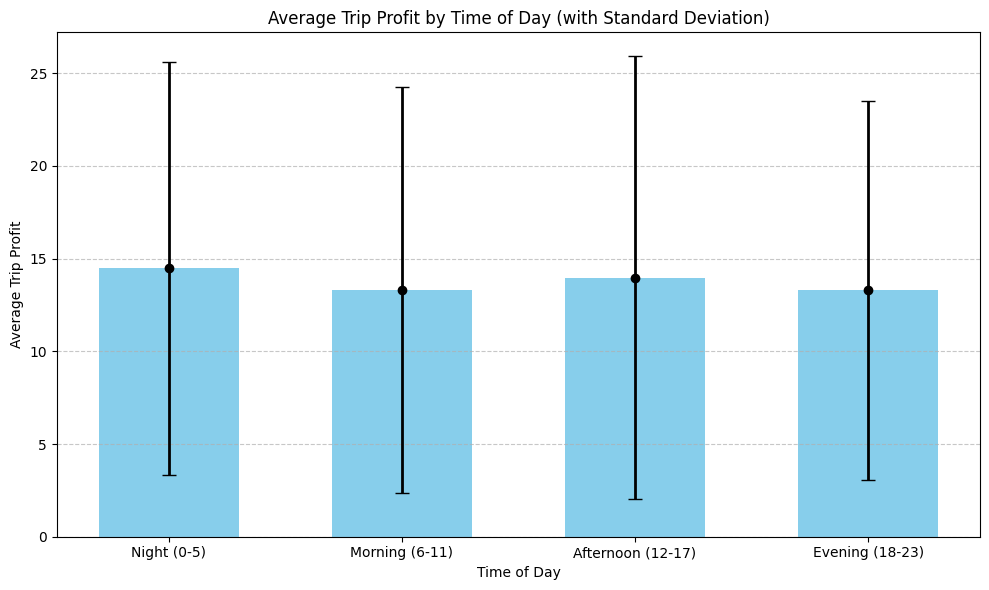

In [ ]:
#@title Visualize the trip profits as a function of the time of day
from pyspark.sql.functions import avg, col, hour, when, stddev, count # Added count
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Extract the hour from 'pickup_datetime'
final_data_with_hour = final_data.withColumn("pickup_hour", hour(col("pickup_datetime")))

# Create time_of_day_bin based on pickup_hour to group the data by time of day
final_data_with_time_bins = final_data_with_hour.withColumn(
    "time_of_day_bin",
    when((col("pickup_hour") >= 6) & (col("pickup_hour") <= 11), "Morning (6-11)")
    .when((col("pickup_hour") >= 12) & (col("pickup_hour") <= 17), "Afternoon (12-17)")
    .when((col("pickup_hour") >= 18) & (col("pickup_hour") <= 23), "Evening (18-23)")
    .otherwise("Night (0-5)")
)

# Group by time_of_day_bin and calculate the average, standard deviation, and count of trip_profit
avg_profit_by_time_of_day = final_data_with_time_bins.groupBy("time_of_day_bin").agg(
    avg("trip_profit").alias("average_trip_profit"),
    stddev("trip_profit").alias("stddev_trip_profit"),
    count("trip_profit").alias("count_trip_profit") # Added count
)

# Define the order for time of day bins for better visualization
time_of_day_bin_order = ["Night (0-5)", "Morning (6-11)", "Afternoon (12-17)", "Evening (18-23)"]

# Convert to Pandas DataFrame and reorder the bins
avg_profit_by_time_of_day_pd = avg_profit_by_time_of_day.toPandas()
avg_profit_by_time_of_day_pd['time_of_day_bin'] = pd.Categorical(avg_profit_by_time_of_day_pd['time_of_day_bin'], categories=time_of_day_bin_order, ordered=True)
avg_profit_by_time_of_day_pd = avg_profit_by_time_of_day_pd.sort_values('time_of_day_bin')

# Create a bar plot and error bars to visualize average trip profit by time of day bin
plt.figure(figsize=(10, 6))

# Get positions for the bars
x_pos = np.arange(len(avg_profit_by_time_of_day_pd))

# Plot the bars
plt.bar(x_pos,
        avg_profit_by_time_of_day_pd['average_trip_profit'],
        color='skyblue',
        width=0.6)

# Add error bars using the standard deviation
plt.errorbar(x_pos,
             avg_profit_by_time_of_day_pd['average_trip_profit'],
             yerr=avg_profit_by_time_of_day_pd['stddev_trip_profit'], # Using stddev for error bars
             fmt='o',          # Format of the data points (dots)
             color='black',    # Color of the error bars
             capsize=5,        # Length of the error bar caps
             elinewidth=2)     # Thickness of the error bar lines

plt.title('Average Trip Profit by Time of Day (with Standard Deviation)')
plt.xlabel('Time of Day')
plt.ylabel('Average Trip Profit')
plt.xticks(x_pos, avg_profit_by_time_of_day_pd['time_of_day_bin'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

As can be observed, the trip profitability varies only so slightly with the time-of-day with no clear trend.

The Night (0-5) trips show the highest average profit, closely followed by the Afternoon (12-17). Morning (6-11) and Evening (18-23) evidence slightly lower profits.

While Night (0-5) appears to have a slightly higher average profit, the differences in average profitability between time slots are not substantial. However, the high standard deviations across all time bins indicate that there's a significant range of profit values within each period. This suggests that other factors beyond just the time of day likely play a role in determining individual trip profitability.

#Conclusions
The main conclusions that can be drawn from this work are:
1. The distribution of the average profitability per area (as defined here) is heavily right-skewed due to the fact that the majority of the trips generate very low profit, while some of the trips generate exceptionally high profit. This observation is confirmed by the histogram and box plot of the profitability data.
2. The average trip profit has a clear dependence on the trip distance, with trips under 1 mile generating the lowest profits and trips above 10 miles generating the highest profits.
3. The average trip profit has no clear dependence on the time of day, with night, morning, afternoon, and evening trips generating almost equivalent profit. However, the standard deviation for each time of day group indicates that there is a significant range of profit values inside each category. This can be due to other factors besides the time of day of the trip.